In [1]:
import yfinance as yf

In [3]:
import numpy as np

In [5]:
dat = yf.Ticker("SPY")

In [7]:
data = dat.history(period = '15y', auto_adjust= False)

In [8]:
data["sm21"] = data["Adj Close"].rolling(21).mean()
data["sm50"] = data["Adj Close"].rolling(50).mean()
data["Ema50"] = data["Adj Close"].ewm(span=20, adjust= False).mean()

In [11]:
data

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains,sm21,sm50,Ema50
Date,,,,,,,,,,,,
2010-12-27 00:00:00-05:00,125.129997,125.769997,125.040001,125.650002,96.121902,58126000,0.000,0.0,0.0,NaN,NaN,96.121902
2010-12-28 00:00:00-05:00,125.900002,125.949997,125.500000,125.830002,96.259598,55309100,0.000,0.0,0.0,NaN,NaN,96.135016
2010-12-29 00:00:00-05:00,125.980003,126.199997,125.900002,125.919998,96.328430,58033100,0.000,0.0,0.0,NaN,NaN,96.153437
2010-12-30 00:00:00-05:00,125.800003,126.129997,125.529999,125.720001,96.175438,76616900,0.000,0.0,0.0,NaN,NaN,96.155532
2010-12-31 00:00:00-05:00,125.529999,125.870003,125.330002,125.750000,96.198402,91218900,0.000,0.0,0.0,NaN,NaN,96.159615
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-17 00:00:00-05:00,679.890015,680.440002,671.200012,671.400024,669.421936,110625200,0.000,0.0,0.0,674.816938,672.845210,677.014516
2025-12-18 00:00:00-05:00,677.599976,680.739990,674.900024,676.469971,674.476929,108650100,0.000,0.0,0.0,675.595110,672.912211,676.772841
2025-12-19 00:00:00-05:00,676.590027,681.090027,676.469971,680.590027,680.590027,103599500,1.993,0.0,0.0,676.543312,673.140359,677.136383


In [13]:
data.shape

(3772, 12)

In [15]:
data["distancia sma21"] = (data.Close - data.sm21) / data.sm21
data["distancia sma50"] = (data.Close - data.sm50) / data.sm50

In [17]:
prueba = data.dropna().copy()

In [19]:
prueba["target"] = prueba["Close"].pct_change().shift(-1)

In [21]:
prueba = prueba.dropna()

In [23]:
import matplotlib.pyplot as plt 

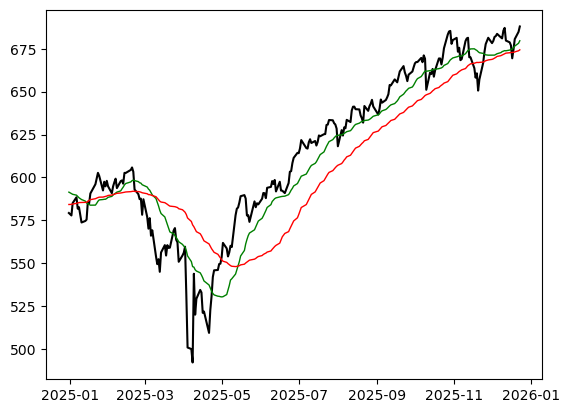

In [24]:
plt.plot(data.loc["2024-12-31":"2025-12-31"]["Adj Close"], c= "blacK")
plt.plot(data.loc["2024-12-31":"2025-12-31"]["sm21"], c= "green", linewidth = 1)
plt.plot(data.loc["2024-12-31":"2025-12-31"]["sm50"], c= "red", linewidth=1)

In [27]:
import seaborn as sns

In [28]:
corr = data.corr()
corr = corr.drop(["Stock Splits", "Capital Gains"], axis= 1)

In [29]:
corr = corr.drop(["Stock Splits","Capital Gains"], axis= 0)

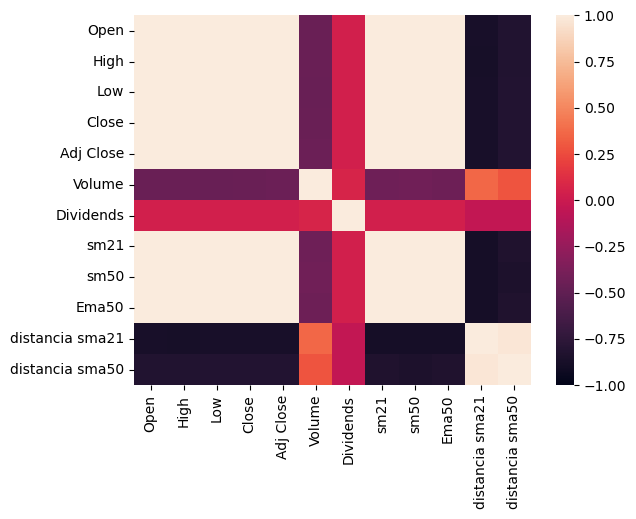

In [33]:
axs = sns.heatmap(corr, vmin=-1, vmax=1)
plt.show()

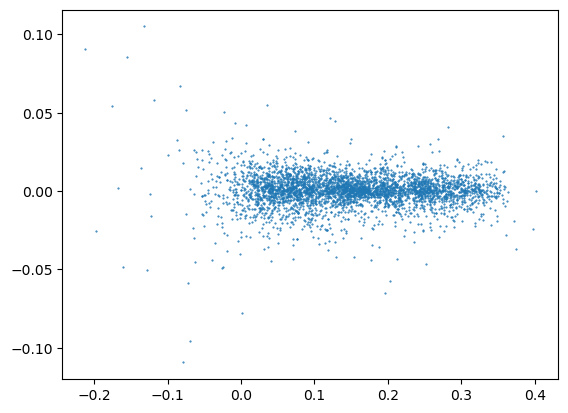

In [35]:
fig, ax = plt.subplots()
ax.scatter(prueba["distancia sma50"], prueba["target"], marker='.', s=1)
plt.show()

In [37]:
prueba

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains,sm21,sm50,Ema50,distancia sma21,distancia sma50,target
Date,,,,,,,,,,,,,,,
2011-03-08 00:00:00-05:00,131.639999,133.000000,131.070007,132.580002,101.423332,174615000,0.000,0.0,0.0,101.367941,99.451154,100.938859,0.307909,0.333117,-0.001433
2011-03-09 00:00:00-05:00,132.320007,132.800003,131.600006,132.389999,101.277908,153806000,0.000,0.0,0.0,101.383237,99.554274,100.971149,0.305837,0.329827,-0.018506
2011-03-10 00:00:00-05:00,131.000000,131.179993,129.809998,129.940002,99.403732,301291800,0.000,0.0,0.0,101.287430,99.617157,100.821871,0.282884,0.304394,0.006926
2011-03-11 00:00:00-05:00,129.520004,131.309998,129.490005,130.839996,100.092224,225621800,0.000,0.0,0.0,101.235339,99.692432,100.752381,0.292434,0.312437,-0.006038
2011-03-14 00:00:00-04:00,129.990005,130.479996,129.059998,130.050003,99.487892,234974100,0.000,0.0,0.0,101.152647,99.758681,100.631954,0.285681,0.303646,-0.011457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-16 00:00:00-05:00,679.229980,681.080017,674.979980,678.869995,676.869934,122030600,0.000,0.0,0.0,674.544884,672.799744,677.813735,0.006412,0.009022,-0.011004
2025-12-17 00:00:00-05:00,679.890015,680.440002,671.200012,671.400024,669.421936,110625200,0.000,0.0,0.0,674.816938,672.845210,677.014516,-0.005063,-0.002148,0.007551
2025-12-18 00:00:00-05:00,677.599976,680.739990,674.900024,676.469971,674.476929,108650100,0.000,0.0,0.0,675.595110,672.912211,676.772841,0.001295,0.005287,0.006091


In [39]:
prueba = prueba.drop(["Open","High","Low","sm21","sm50","Ema50", "Close","Stock Splits", "Capital Gains"], axis=1)

In [41]:
from sklearn.model_selection import train_test_split

In [43]:
y = prueba["target"]
x = prueba.drop(["Adj Close", "target"], axis=1)

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42, shuffle = False)

In [47]:
y_train.to_frame()

,target
Date,
2011-03-08 00:00:00-05:00,-0.001433
2011-03-09 00:00:00-05:00,-0.018506
2011-03-10 00:00:00-05:00,0.006926
2011-03-11 00:00:00-05:00,-0.006038
2011-03-14 00:00:00-04:00,-0.011457
...,...
2022-12-27 00:00:00-05:00,-0.012428
2022-12-28 00:00:00-05:00,0.018000
2022-12-29 00:00:00-05:00,-0.002634


In [49]:
from sklearn.preprocessing import StandardScaler

In [51]:
std_scaler = StandardScaler()

In [53]:
x_train_scaled = std_scaler.fit_transform(x_train)

In [55]:
from sklearn.linear_model import LinearRegression

In [57]:
modelo= LinearRegression()

In [59]:
modelo.fit(x_train_scaled, y_train)

LinearRegression()

In [61]:
x_test_scaled = std_scaler.transform(x_test)

In [63]:
prediccion = modelo.predict(x_test_scaled)

In [65]:
 from sklearn.metrics import mean_absolute_error

In [67]:
error_counter = mean_absolute_error(prediccion, y_test)
error_counter

0.006602686795235239

In [69]:
#hacer pipeline

In [73]:
resp = 0.006602686795235239*100
resp

0.6602686795235239

In [75]:
from sklearn.pipeline import Pipeline

In [77]:
pipe = Pipeline([('scaler', StandardScaler()),('linear',LinearRegression())])

In [79]:
pipe.fit(x_train, y_train)
pipe

Pipeline(steps=[('scaler', StandardScaler()), ('linear', LinearRegression())])

In [81]:
pipePrediction = pipe.predict(x_test)

In [83]:
error_counter = mean_absolute_error(pipePrediction, y_test)

In [85]:
error_counter

0.006602686795235239

In [79]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [262]:
import joblib as jb 

In [264]:
from pathlib import Path

In [266]:
location = Path('C:/Users/Usuario/Desktop/proyecto finance/memory')

In [268]:
loc_archivo = Path('C:/Users/Usuario/Desktop/proyecto finance/memory/linear.joblib')

In [270]:
mem = Memory(location, verbose=1)

In [272]:
jb.dump(pipe, loc_archivo )

['C:\\Users\\Usuario\\Desktop\\proyecto finance\\memory\\linear.joblib']

In [344]:
modelo_archivado = jb.load(loc_archivo)

In [346]:
prueba2 = modelo_archivado.predict(x_test.head(5))

In [348]:
prueba2

array([0.00144838, 0.00131738, 0.00119688, 0.00133687, 0.00139042])

In [350]:
resultadoPrueba2 = mean_absolute_error(prueba2, y_test.head(5))

In [352]:
resultadoPrueba2

0.00895623017845996